In [5]:
import sys
import os

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [6]:
import os

#Definir las rutas de exportación para gráficos/reportes
PATH_FIGURES = "../outputs/plots"
PATH_REPORTS = "../outputs/reports"

#Crear carpetas si no existen
os.makedirs(PATH_FIGURES, exist_ok=True)
os.makedirs(PATH_REPORTS, exist_ok=True)

# Fase 0: Análisis de datos
El análisis de datos considera usar el dataset limpio que fue creado en la experiencia pasada.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.carga import cargar_csv

In [8]:
dfa = cargar_csv("..\data\processed\Student_Depression_Dataset_Limpio.csv")
dfa.head()

,id,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## **Reportes**

In [9]:
#Resumen estadístico general
resumen = dfa.describe()
resumen.to_csv(os.path.join(PATH_REPORTS, "00_resumen_estadistico_general.csv"))

### Distribución general de depresión

In [10]:
dist = dfa["Depression"].value_counts(normalize=True) * 100
dist = dist.reset_index()
dist["Depression"] = dist["Depression"].map({1:"Sí", 0:"No"})
dist.columns = ["¿Tiene depresión?","Distribución (%)"]
dist.to_csv(os.path.join(PATH_REPORTS, "01_distribucion_general_depresion.csv"), index=False)
dist

,¿Tiene depresión?,Distribución (%)
0,Sí,58.575691
1,No,41.424309


### ¿Algún género experimenta más frecuentemente pensamientos s**cidas?

In [11]:
pens_s = pd.crosstab(dfa["Gender"], dfa["Have you ever had suicidal thoughts ?"])

pens_s["%"] = pens_s["Yes"] * 100 / (pens_s["No"] + pens_s["Yes"])
pens_s.index = ["Femenino", "Masculino"]
pens_s.columns = ["No ha pensado en eso", "Sí ha pensado en eso", "Proporción de pensamientos suicidas (%)"]
pens_s.to_csv(os.path.join(PATH_REPORTS, "02_proporcion_pensamientos_por_genero.csv"))
pens_s

,No ha pensado en eso,Sí ha pensado en eso,Proporción de pensamientos suicidas (%)
Femenino,4511,7804,63.369874
Masculino,5701,9801,63.224100


¿Ocurre lo mismo con la depresión?

In [12]:
depresion = pd.crosstab(dfa["Gender"], dfa["Depression"])

depresion["%"] = depresion[1] * 100 / (depresion[0] + depresion[1])
depresion.index = ["Femenino", "Masculino"]
depresion.columns = ["No posee depresión", "Sí posee depresión", "Proporción de depresión (%)"]
depresion.to_csv(os.path.join(PATH_REPORTS, "03_proporcion_depresion_por_genero.csv"))
depresion

,No posee depresión,Sí posee depresión,Proporción de depresión (%)
Femenino,5113,7202,58.481527
Masculino,6410,9092,58.650497


### ¿Cómo influyen las horas de sueño en la depresión?

In [13]:
ct_sleep = pd.crosstab(dfa["Sleep Duration"], dfa["Depression"], normalize="index") * 100
ct_sleep = ct_sleep.round(2)

ct_sleep = ct_sleep.reset_index()
ct_sleep.columns = ["Duración del sueño", "NO Tiene depresión", "Tiene Depresión"]
ct_sleep.to_csv(os.path.join(PATH_REPORTS, "04_influencia_sueño_en_depresion.csv"), index=False)
ct_sleep

,Duración del sueño,NO Tiene depresión,Tiene Depresión
0,5-6 hours,43.12,56.88
1,7-8 hours,40.45,59.55
2,Less than 5 hours,35.46,64.54
3,More than 8 hours,49.06,50.94


### Top 10 ciudades con más índice de depresión ¿El estrés financiero o el historial familiar influyen?

In [14]:
df_format = dfa.copy()
df_format["Family History of Mental Illness"] = df_format["Family History of Mental Illness"].map({"Yes": 1, "No": 0})

reporte_ciudades = df_format.groupby("City")[["Depression", "Financial Stress", "Family History of Mental Illness"]].mean().round(2)
top_10_completo = reporte_ciudades.sort_values(by="Depression", ascending=False).head(10)

top_10_completo = top_10_completo.reset_index()
top_10_completo.columns = ["Ciudad", "Tasa de Depresión", "Promedio Estrés Financiero", "Historial Familiar"]
top_10_completo.to_csv(os.path.join(PATH_REPORTS, "05_top_10_ciudades_mayor_depresion.csv"), index=False)

top_10_completo

,Ciudad,Tasa de Depresión,Promedio Estrés Financiero,Historial Familiar
0,Hyderabad,0.67,3.27,0.53
1,Ahmedabad,0.67,3.26,0.48
2,Rajkot,0.63,3.13,0.55
3,Patna,0.63,3.27,0.47
4,Bhopal,0.62,3.09,0.51
5,Bangalore,0.61,3.17,0.49
6,Delhi,0.61,3.21,0.49
7,Kolkata,0.61,3.11,0.48
8,Indore,0.61,3.17,0.48
9,Kalyan,0.60,3.13,0.43


### Horas de trabajo/estudio: ¿Producen un cambio en el CGPA o en la presión académica percibida?

In [15]:
reporte_horas = dfa.groupby("Work/Study Hours")[["CGPA", "Academic Pressure"]].mean().round(2)
reporte_horas = reporte_horas.reset_index()
reporte_horas.columns = ["Horas de trabajo/estudio diarias", "CGPA promedio", "Presión Académica promedio"]
reporte_horas.to_csv(os.path.join(PATH_REPORTS, "06_cgpa_y_presión_según_horas_estudio.csv"), index=False)
reporte_horas

,Horas de trabajo/estudio diarias,CGPA promedio,Presión Académica promedio
0,0.0,7.62,2.75
1,1.0,7.71,2.92
2,2.0,7.65,3.00
3,3.0,7.77,3.04
4,4.0,7.65,3.07
5,5.0,7.64,3.11
6,6.0,7.57,3.15
7,7.0,7.64,3.16
8,8.0,7.60,3.18
9,9.0,7.72,3.15


## **Gráficos**

### ¿En qué rango etario se manifiesta más la depresión?

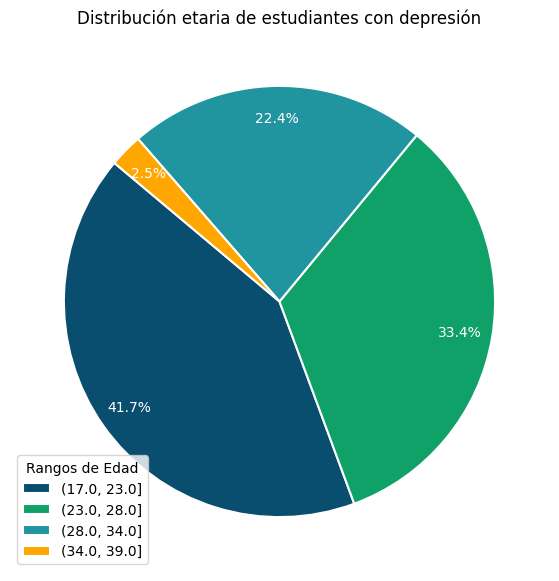

In [16]:
personas_deprimidas = dfa[dfa["Depression"] == 1].copy()
personas_deprimidas["Rango Age"] = pd.cut(personas_deprimidas["Age"], bins=4, precision=0, include_lowest=True)
conteo_por_rango = personas_deprimidas.groupby("Rango Age", observed=False).size()
colores = ["#094e6e", "#0fa167", "#2095A0", "#ffa600"]

plt.figure(figsize=(10, 7))
plt.pie(conteo_por_rango, labels=None, autopct='%1.1f%%', textprops={'color': "white", "fontsize":10},
        startangle=140, pctdistance=0.85, colors=colores, wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
plt.legend(conteo_por_rango.index, title="Rangos de Edad", )
plt.title("Distribución etaria de estudiantes con depresión")
plt.savefig(os.path.join(PATH_FIGURES, "01_distribucion_etaria_depresion.png"), bbox_inches="tight", dpi=300)
plt.show()

### ¿La presión académica es mayor en algunas carreras por sobre otras?

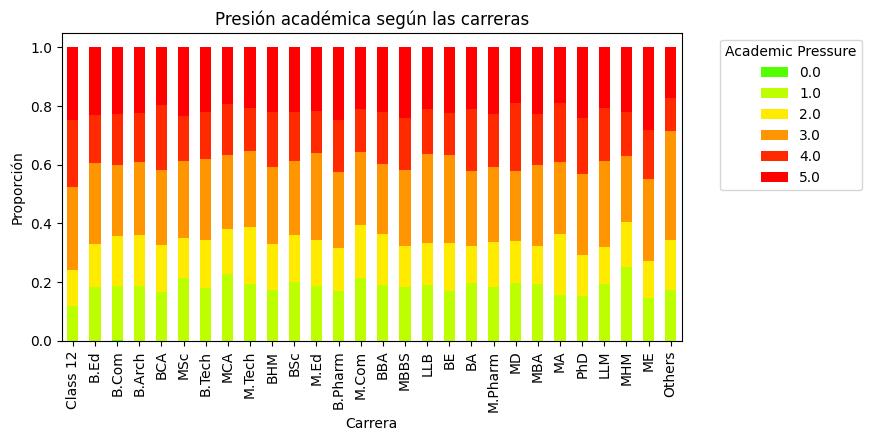

In [17]:
tabla = pd.crosstab(dfa["Degree"],  dfa["Academic Pressure"],  normalize="index")
tabla = tabla.loc[dfa["Degree"].value_counts().index]
tabla.plot(kind="bar", stacked=True, colormap="prism_r", figsize=(8,4))

plt.xticks(rotation=90)
plt.xlabel("Carrera")
plt.ylabel("Proporción")
plt.title("Presión académica según las carreras")
plt.legend(title="Academic Pressure", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig(os.path.join(PATH_FIGURES, "02_presion_academica_carreras.png"), bbox_inches="tight", dpi=300)
plt.show()

### ¿Qué variable influye de forma más directa en la depresión?

¿Las horas de trabajo/estudio? ¿La presión académica? ¿O el estrés financiero?

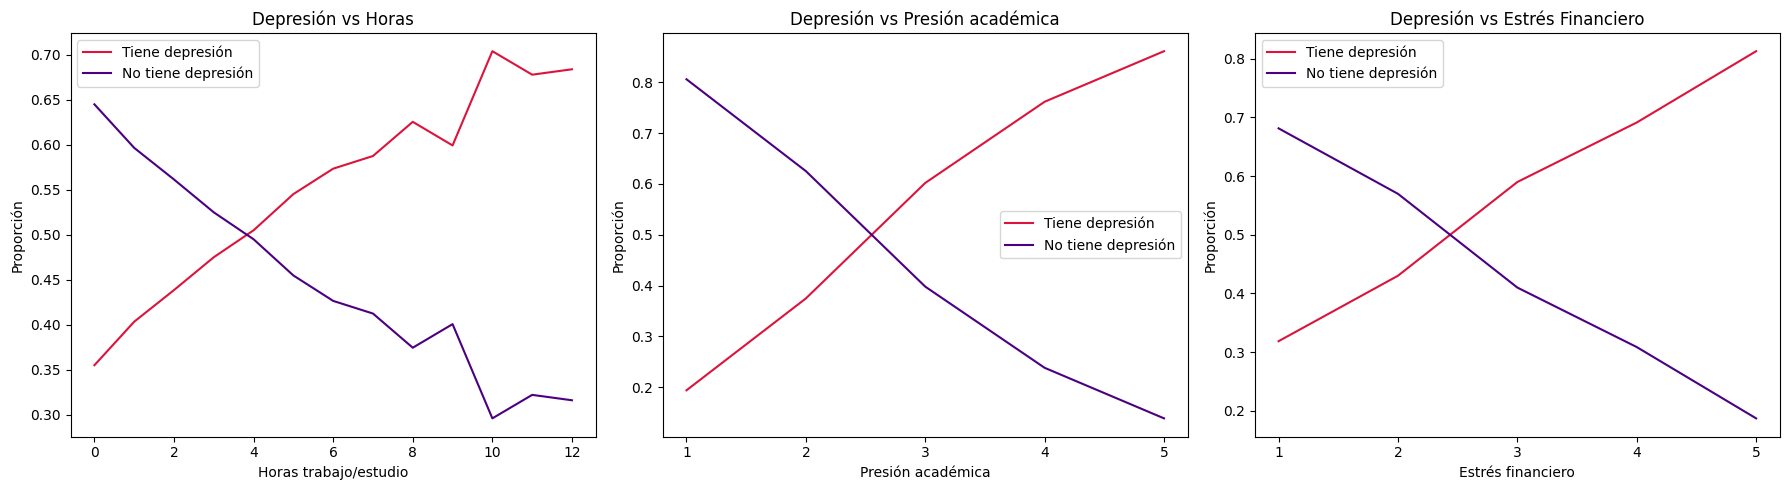

In [18]:
# Horas de trabajo/estudio
deprimidos_por_horas = pd.crosstab(dfa["Work/Study Hours"], dfa["Depression"], normalize="index")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(deprimidos_por_horas.index, deprimidos_por_horas[1], color="crimson", label="Tiene depresión")
axes[0].plot(deprimidos_por_horas.index, deprimidos_por_horas[0], color="indigo", label="No tiene depresión")
axes[0].set_xlabel("Horas trabajo/estudio")
axes[0].set_ylabel("Proporción")
axes[0].set_title("Depresión vs Horas")
axes[0].legend()

# Presión académica 
presion = dfa[dfa["Academic Pressure"] > 0].copy()
deprimidos_por_presion = pd.crosstab(presion["Academic Pressure"],  presion["Depression"], normalize="index")
axes[1].plot(deprimidos_por_presion.index, deprimidos_por_presion[1], color="crimson", label="Tiene depresión")
axes[1].plot(deprimidos_por_presion.index, deprimidos_por_presion[0], color="indigo", label="No tiene depresión")
axes[1].set_xlabel("Presión académica")
axes[1].set_ylabel("Proporción")
axes[1].set_title("Depresión vs Presión académica")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].legend()

# Estrés financiero
deprimidos_por_estres = pd.crosstab(dfa["Financial Stress"], dfa["Depression"], normalize="index")
axes[2].plot(deprimidos_por_estres.index, deprimidos_por_estres[1], color="crimson", label="Tiene depresión")
axes[2].plot(deprimidos_por_estres.index, deprimidos_por_estres[0], color="indigo", label="No tiene depresión")
axes[2].set_xlabel("Estrés financiero")
axes[2].set_ylabel("Proporción")
axes[2].set_title("Depresión vs Estrés Financiero")
axes[2].set_xticks([1, 2, 3, 4, 5])
axes[2].legend()

plt.savefig(os.path.join(PATH_FIGURES, "03_influencia_variables_en_depresion.png"), bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()

### ¿Un CGPA alto implica mayor satisfacción por los estudios?

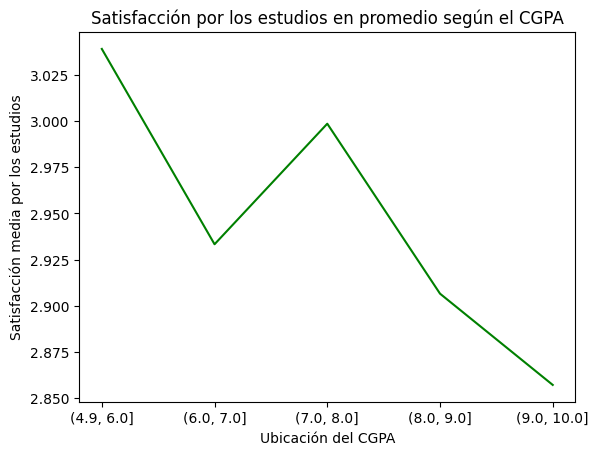

In [19]:
carreras_distintas = dfa.copy()
carreras_distintas["Rango CGPA"] = pd.cut(carreras_distintas["CGPA"], bins = 5, precision=1, include_lowest=True)
satisfaccion_media = carreras_distintas.groupby("Rango CGPA", observed=False)["Study Satisfaction"].mean()

plt.plot(satisfaccion_media.index.astype(str), satisfaccion_media.values, color="green")

plt.xlabel("Ubicación del CGPA")
plt.ylabel("Satisfacción media por los estudios")
plt.title("Satisfacción por los estudios en promedio según el CGPA")
plt.savefig(os.path.join(PATH_FIGURES, "04_satisfaccion_estudios_segun_cgpa.png"), bbox_inches="tight", dpi=300)
plt.show()

### ¿Las personas que no duermen bien también se les dificulta alimentarse bien?

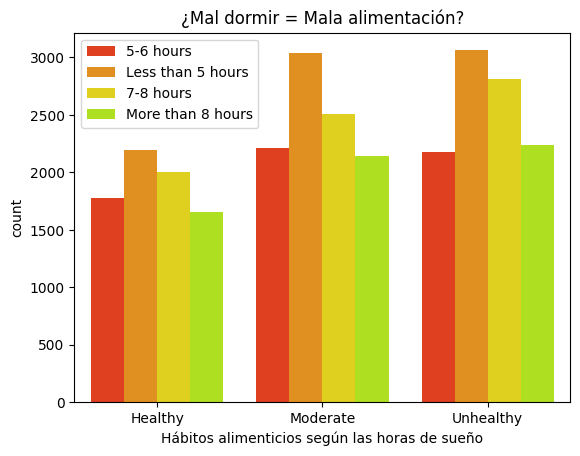

In [20]:
sns.countplot(data=dfa, x="Dietary Habits", hue="Sleep Duration", palette="prism")
plt.xlabel("Hábitos alimenticios según las horas de sueño")
plt.title("¿Mal dormir = Mala alimentación?")
plt.savefig(os.path.join(PATH_FIGURES, "05_comparacion_sueño_alimentacion.png"), bbox_inches="tight", dpi=300)
plt.legend()
plt.show()

### Mapa de calor para correlaciones con variables numéricas y binarias

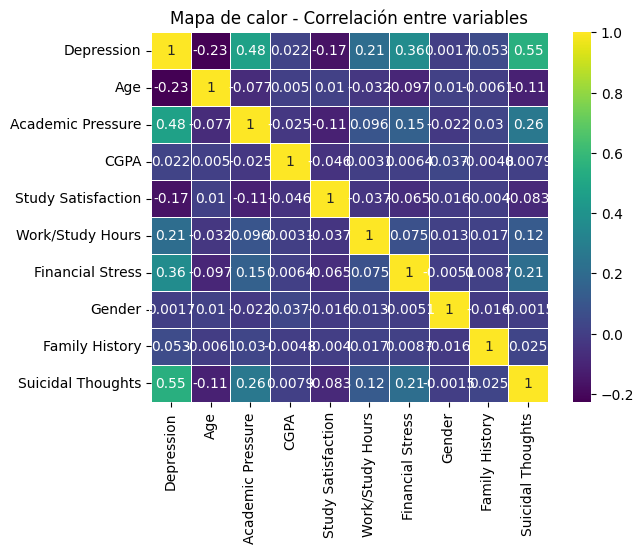

In [21]:
estudio_correlacion = dfa.select_dtypes(include=["int64", "float64"])
estudio_correlacion.drop(columns=["id"], inplace=True) #No aporta información relevante

# Variables binarias transformadas a número
estudio_correlacion["Gender"] = dfa["Gender"].map({"Male": 1, "Female": 0}) 
estudio_correlacion["Family History"] = dfa["Family History of Mental Illness"].map({"Yes": 1, "No": 0})
estudio_correlacion["Suicidal Thoughts"] = dfa["Have you ever had suicidal thoughts ?"].map({"Yes": 1, "No": 0})

cols = list(estudio_correlacion.columns)
cols.insert(0, cols.pop(cols.index("Depression"))) 
estudio_correlacion = estudio_correlacion[cols]

sns.heatmap(estudio_correlacion.corr(), annot=True, cmap="viridis", linecolor="white", linewidths=0.5)
plt.title("Mapa de calor - Correlación entre variables")
plt.xticks(rotation=90)
plt.savefig(os.path.join(PATH_FIGURES, "06_heatmap_correlacion.png"), bbox_inches="tight", dpi=300)
plt.show()